# Beverage Quality Model Improvement

This notebook replaces the single ElasticNet baseline with a reproducible model-selection workflow. The target is the discrete `quality` score, so the final regressor is evaluated both with regression metrics and with rounded exact-quality accuracy.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd

from sklearn.ensemble import ExtraTreesRegressor, GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import ElasticNet, Ridge
from sklearn.metrics import accuracy_score, f1_score, mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 42
TEST_SIZE = 0.20

root = Path.cwd()
if not (root / "data" / "Drinks-data.csv").exists():
    root = root.parent

DATA_PATH = root / "data" / "Drinks-data.csv"
DATA_PATH

WindowsPath('G:/Inception End to End Project/Beverage-Quality-Assessment/data/Drinks-data.csv')

In [2]:
data = pd.read_csv(DATA_PATH)
print(f"Rows: {data.shape[0]:,} | Columns: {data.shape[1]:,}")
display(data.head())

Rows: 1,599 | Columns: 12


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [3]:
display(data.describe().T)
print("Missing values:")
display(data.isnull().sum())
print("Quality distribution:")
display(data["quality"].value_counts().sort_index())

,count,mean,std,min,25%,50%,75%,max
fixed acidity,1599.0,8.319637,1.741096,4.60000,7.1000,7.90000,9.200000,15.90000
volatile acidity,1599.0,0.527821,0.179060,0.12000,0.3900,0.52000,0.640000,1.58000
citric acid,1599.0,0.270976,0.194801,0.00000,0.0900,0.26000,0.420000,1.00000
residual sugar,1599.0,2.538806,1.409928,0.90000,1.9000,2.20000,2.600000,15.50000
chlorides,1599.0,0.087467,0.047065,0.01200,0.0700,0.07900,0.090000,0.61100
free sulfur dioxide,1599.0,15.874922,10.460157,1.00000,7.0000,14.00000,21.000000,72.00000
total sulfur dioxide,1599.0,46.467792,32.895324,6.00000,22.0000,38.00000,62.000000,289.00000
density,1599.0,0.996747,0.001887,0.99007,0.9956,0.99675,0.997835,1.00369
pH,1599.0,3.311113,0.154386,2.74000,3.2100,3.31000,3.400000,4.01000
sulphates,1599.0,0.658149,0.169507,0.33000,0.5500,0.62000,0.730000,2.00000


Missing values:


fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

Quality distribution:


quality
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64

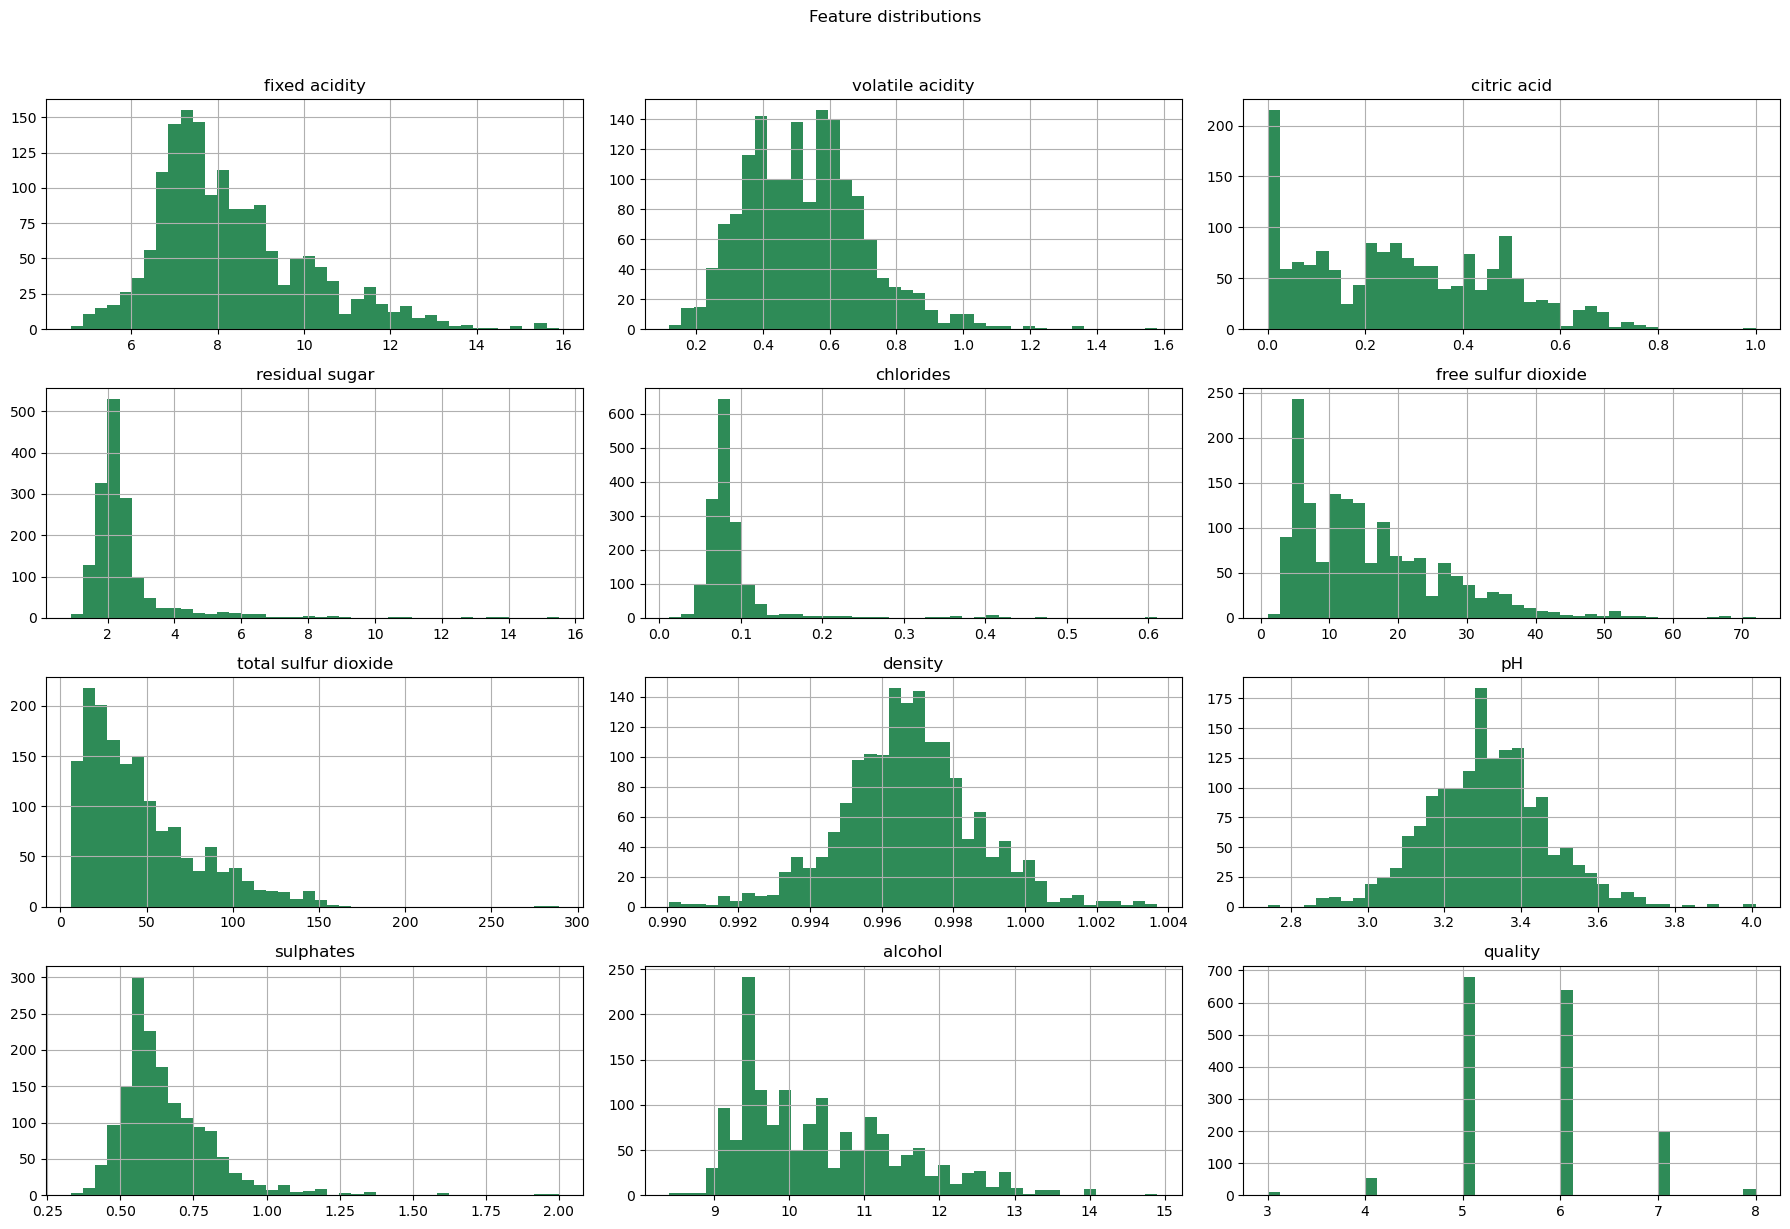

In [4]:
import matplotlib.pyplot as plt

axes = data.hist(bins=40, figsize=(18, 12), color="seagreen")
plt.suptitle("Feature distributions", y=1.02)
plt.tight_layout()
plt.show()

## Train/Test Split

The target classes are imbalanced, so the holdout split is stratified by `quality`. This keeps rare quality scores represented in both training and test data.

In [5]:
X = data.drop(columns="quality")
y = data["quality"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

print("Train:", X_train.shape, y_train.shape)
print("Test:", X_test.shape, y_test.shape)

Train: (1279, 11) (1279,)
Test: (320, 11) (320,)


In [6]:
def rmse_score(actual, predicted):
    return float(np.sqrt(mean_squared_error(actual, predicted)))


def rounded_quality(predicted, min_quality=None, max_quality=None):
    min_quality = y.min() if min_quality is None else min_quality
    max_quality = y.max() if max_quality is None else max_quality
    return np.clip(np.rint(predicted), min_quality, max_quality).astype(int)


def evaluate_regressor(model, X_test, y_test):
    predicted = model.predict(X_test)
    rounded = rounded_quality(predicted)

    return {
        "rmse": rmse_score(y_test, predicted),
        "mae": float(mean_absolute_error(y_test, predicted)),
        "r2": float(r2_score(y_test, predicted)),
        "rounded_accuracy": float(accuracy_score(y_test, rounded)),
        "rounded_f1_macro": float(f1_score(y_test, rounded, average="macro")),
    }

## Baseline

This recreates the original ElasticNet-style model so the improved model has a direct comparison point.

In [7]:
baseline_model = ElasticNet(alpha=0.1, l1_ratio=0.5, random_state=RANDOM_STATE)
baseline_model.fit(X_train, y_train)

baseline_metrics = evaluate_regressor(baseline_model, X_test, y_test)
pd.DataFrame([baseline_metrics], index=["ElasticNet baseline"]).round(4)

,rmse,mae,r2,rounded_accuracy,rounded_f1_macro
ElasticNet baseline,0.7,0.5603,0.2405,0.5438,0.2139


## Model Benchmark

Tree ensembles usually perform better on this small tabular dataset because they capture nonlinear relationships without manual feature engineering. `n_jobs=1` is intentional so the notebook runs in restricted Windows environments where multiprocessing can fail.

In [8]:
candidate_models = {
    "ElasticNet scaled": Pipeline(
        steps=[
            ("scaler", StandardScaler()),
            ("model", ElasticNet(alpha=0.1, l1_ratio=0.5, random_state=RANDOM_STATE)),
        ]
    ),
    "Ridge scaled": Pipeline(
        steps=[
            ("scaler", StandardScaler()),
            ("model", Ridge(alpha=1.0)),
        ]
    ),
    "RandomForestRegressor": RandomForestRegressor(
        n_estimators=300,
        min_samples_leaf=2,
        random_state=RANDOM_STATE,
        n_jobs=1,
    ),
    "ExtraTreesRegressor": ExtraTreesRegressor(
        n_estimators=300,
        min_samples_leaf=1,
        random_state=RANDOM_STATE,
        n_jobs=1,
    ),
    "GradientBoostingRegressor": GradientBoostingRegressor(random_state=RANDOM_STATE),
}

benchmark_rows = []
for name, model in candidate_models.items():
    model.fit(X_train, y_train)
    metrics = evaluate_regressor(model, X_test, y_test)
    benchmark_rows.append({"model": name, **metrics})

benchmark = pd.DataFrame(benchmark_rows).sort_values("rounded_accuracy", ascending=False)
display(benchmark.round(4))

,model,rmse,mae,r2,rounded_accuracy,rounded_f1_macro
3,ExtraTreesRegressor,0.5527,0.3724,0.5267,0.6719,0.4167
2,RandomForestRegressor,0.5720,0.4285,0.4930,0.6500,0.3457
4,GradientBoostingRegressor,0.6124,0.4749,0.4189,0.5969,0.2889
1,Ridge scaled,0.6374,0.4951,0.3704,0.5938,0.2695
0,ElasticNet scaled,0.6545,0.5192,0.3361,0.5906,0.2371


## Hyperparameter Search

The benchmark identifies ExtraTrees as the best candidate. The randomized search below tunes it with stratified 5-fold cross-validation and optimizes RMSE while still reporting rounded exact-quality accuracy.

In [9]:
param_distributions = {
    "n_estimators": [200, 300, 500, 800],
    "max_depth": [None, 8, 12, 16, 24, 32],
    "min_samples_split": [2, 4, 6, 10],
    "min_samples_leaf": [1, 2, 3, 4],
    "max_features": [None, "sqrt", 0.7, 0.9],
    "bootstrap": [False, True],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

search = RandomizedSearchCV(
    estimator=ExtraTreesRegressor(random_state=RANDOM_STATE, n_jobs=1),
    param_distributions=param_distributions,
    n_iter=35,
    scoring="neg_root_mean_squared_error",
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=1,
)

search.fit(X_train, y_train)

print("Best CV RMSE:", round(-search.best_score_, 4))
print("Best parameters:")
search.best_params_

Best CV RMSE: 0.577
Best parameters:


{'n_estimators': 500,
 'min_samples_split': 2,
 'min_samples_leaf': 1,
 'max_features': 0.9,
 'max_depth': None,
 'bootstrap': False}

In [10]:
best_model = search.best_estimator_
best_metrics = evaluate_regressor(best_model, X_test, y_test)

comparison = pd.DataFrame(
    [baseline_metrics, best_metrics],
    index=["ElasticNet baseline", "Tuned ExtraTreesRegressor"],
)
comparison["accuracy_gain"] = comparison["rounded_accuracy"] - comparison.loc["ElasticNet baseline", "rounded_accuracy"]
comparison.round(4)

,rmse,mae,r2,rounded_accuracy,rounded_f1_macro,accuracy_gain
ElasticNet baseline,0.7000,0.5603,0.2405,0.5438,0.2139,0.0000
Tuned ExtraTreesRegressor,0.5481,0.3702,0.5345,0.6781,0.3960,0.1344


In [11]:
predicted_quality = rounded_quality(best_model.predict(X_test))
results = pd.DataFrame({
    "actual_quality": y_test.values,
    "predicted_quality": predicted_quality,
    "raw_prediction": best_model.predict(X_test),
})

display(results.head(15))
print("Exact rounded-quality accuracy:", round(accuracy_score(y_test, predicted_quality), 4))
print("Macro F1:", round(f1_score(y_test, predicted_quality, average="macro"), 4))

,actual_quality,predicted_quality,raw_prediction
0,6,6,6.452
1,5,6,5.658
2,5,5,4.860
3,5,6,5.582
4,6,5,5.458
5,6,6,5.786
6,5,6,5.618
7,4,5,4.818
8,6,5,5.484
9,8,8,8.000


Exact rounded-quality accuracy: 0.6781
Macro F1: 0.396


,feature,importance
10,alcohol,0.2504
1,volatile acidity,0.1296
9,sulphates,0.1216
6,total sulfur dioxide,0.0788
3,residual sugar,0.0653
2,citric acid,0.0651
7,density,0.0607
8,pH,0.0603
0,fixed acidity,0.0568
5,free sulfur dioxide,0.0562


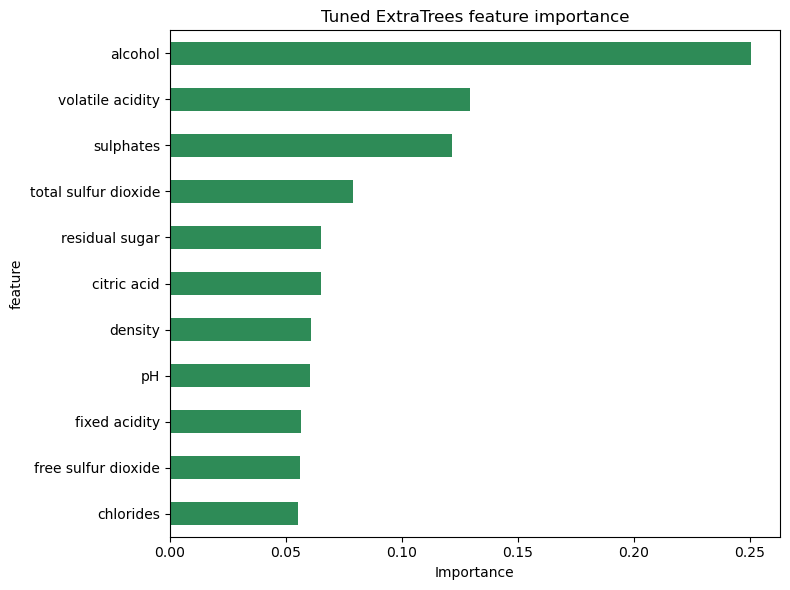

In [12]:
feature_importance = pd.DataFrame({
    "feature": X.columns,
    "importance": best_model.feature_importances_,
}).sort_values("importance", ascending=False)

display(feature_importance.round(4))

feature_importance.plot.barh(x="feature", y="importance", figsize=(8, 6), color="seagreen", legend=False)
plt.gca().invert_yaxis()
plt.title("Tuned ExtraTrees feature importance")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()